# TT-21 - KNN Regressor: Dinh gia nha theo cac can tuong tu
Du lieu: California Housing (giong TT-11 de so sanh truc tiep Linear vs KNN).


## 1. Nap du lieu, xu ly outlier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing(as_frame=True)
df = data.frame.rename(columns={"MedHouseVal": "target"})

X = df.drop(columns="target")
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# clip theo phan vi 99 CHI tren train, tranh ro ri du lieu tu test sang tham so xu ly
outlier_cols = ["AveRooms", "AveBedrms", "AveOccup"]
caps = X_train[outlier_cols].quantile(0.99)
X_train[outlier_cols] = X_train[outlier_cols].clip(upper=caps, axis=1)
X_test[outlier_cols] = X_test[outlier_cols].clip(upper=caps, axis=1)


## 2. Baseline: DummyRegressor + Linear Regression

In [2]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

def danh_gia(model, ten):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{ten:30s} RMSE={rmse:.4f}  R2={r2:.4f}")
    return rmse, r2

rmse_baseline, r2_baseline = danh_gia(DummyRegressor(strategy="mean"), "Baseline (mean)")
rmse_linear, r2_linear = danh_gia(LinearRegression(), "Linear Regression")


Baseline (mean)                RMSE=1.1449  R2=-0.0002
Linear Regression              RMSE=0.6795  R2=0.6477


## 3. KNN KHONG scale

In [3]:
from sklearn.neighbors import KNeighborsRegressor

rmse_khong_scale, r2_khong_scale = danh_gia(
    KNeighborsRegressor(n_neighbors=5, n_jobs=-1), "KNN (khong scale)")
# Population tinh bang hang nghin trong khi cac cot khac chi vai don vi
# -> khoang cach Euclid bi Population ap dao hoan toan, cac dac trung khac gan nhu vo nghia


KNN (khong scale)              RMSE=1.0572  R2=0.1472


## 4. KNN co scale, K=5

In [4]:
def tao_knn(n_neighbors=10, weights="distance", metric="minkowski", p=2):
    return Pipeline([
        ("scale", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights,
                                     metric=metric, p=p, n_jobs=-1)),
    ])

rmse_co_scale, r2_co_scale = danh_gia(tao_knn(n_neighbors=5, weights="uniform"), "KNN (co scale, K=5)")

print(f"\nBang so sanh CO/KHONG chuan hoa:")
print(f"Khong scale: RMSE={rmse_khong_scale:.4f}")
print(f"Co scale:    RMSE={rmse_co_scale:.4f}")


KNN (co scale, K=5)            RMSE=0.6051  R2=0.7206

Bang so sanh CO/KHONG chuan hoa:
Khong scale: RMSE=1.0572
Co scale:    RMSE=0.6051


## 5. RMSE train/test theo K = 1..50

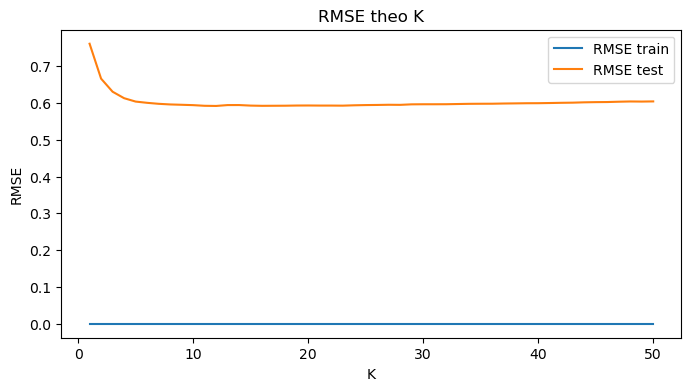

K toi uu (RMSE test thap nhat): 12


In [5]:
K_list = list(range(1, 51))
rmse_train_list, rmse_test_list = [], []
for k in K_list:
    m = tao_knn(n_neighbors=k, weights="distance")
    m.fit(X_train, y_train)
    rmse_train_list.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    rmse_test_list.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

plt.figure(figsize=(8, 4))
plt.plot(K_list, rmse_train_list, label="RMSE train")
plt.plot(K_list, rmse_test_list, label="RMSE test")
plt.xlabel("K"); plt.ylabel("RMSE")
plt.title("RMSE theo K")
plt.legend()
plt.show()

k_toi_uu = K_list[int(np.argmin(rmse_test_list))]
print(f"K toi uu (RMSE test thap nhat): {k_toi_uu}")
# Tai K=1, du doan cua moi diem train chinh la gia tri cua no (voi weights=distance,
# khoang cach den chinh no = 0) -> RMSE train = 0, day la overfit tuyet doi, khong phan anh
# kha nang tong quat hoa -> khong duoc chon K theo RMSE train


## 6. So sanh weights uniform vs distance

In [6]:
for w in ["uniform", "distance"]:
    danh_gia(tao_knn(n_neighbors=k_toi_uu, weights=w), f"KNN (K={k_toi_uu}, weights={w})")


KNN (K=12, weights=uniform)    RMSE=0.5951  R2=0.7297
KNN (K=12, weights=distance)   RMSE=0.5918  R2=0.7327


## 7. So sanh metric euclidean vs manhattan

In [7]:
for metric, p in [("minkowski", 2), ("minkowski", 1)]:
    ten_metric = "euclidean" if p == 2 else "manhattan"
    danh_gia(tao_knn(n_neighbors=k_toi_uu, weights="distance", metric=metric, p=p),
             f"KNN (metric={ten_metric})")


KNN (metric=euclidean)         RMSE=0.5918  R2=0.7327
KNN (metric=manhattan)         RMSE=0.5701  R2=0.7520


## 8. Thi nghiem trong so vi tri: nhan Lat/Lon

He so vi tri x1: RMSE=0.5918
He so vi tri x2: RMSE=0.5544
He so vi tri x3: RMSE=0.5318
He so vi tri x5: RMSE=0.5034


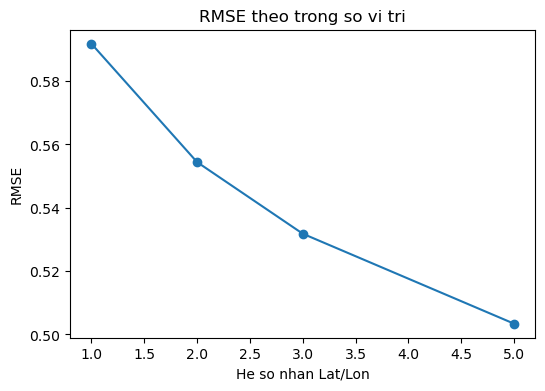

In [8]:
rmse_theo_he_so = {}
for he_so in [1, 2, 3, 5]:
    X_train_w = X_train.copy()
    X_test_w = X_test.copy()
    # nhan Lat/Lon SAU KHI scale se lech thang do, nen scale truoc roi nhan rieng
    scaler = StandardScaler().fit(X_train_w)
    X_train_s = pd.DataFrame(scaler.transform(X_train_w), columns=X_train_w.columns, index=X_train_w.index)
    X_test_s = pd.DataFrame(scaler.transform(X_test_w), columns=X_test_w.columns, index=X_test_w.index)
    for col in ["Latitude", "Longitude"]:
        X_train_s[col] *= he_so
        X_test_s[col] *= he_so

    knn = KNeighborsRegressor(n_neighbors=k_toi_uu, weights="distance", n_jobs=-1)
    knn.fit(X_train_s, y_train)
    rmse_theo_he_so[he_so] = np.sqrt(mean_squared_error(y_test, knn.predict(X_test_s)))
    print(f"He so vi tri x{he_so}: RMSE={rmse_theo_he_so[he_so]:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(list(rmse_theo_he_so.keys()), list(rmse_theo_he_so.values()), marker="o")
plt.xlabel("He so nhan Lat/Lon"); plt.ylabel("RMSE")
plt.title("RMSE theo trong so vi tri")
plt.show()


## 9. Vi du 5 can tuong tu cho 3 can nha bat ky

In [9]:
knn_final = tao_knn(n_neighbors=k_toi_uu, weights="distance")
knn_final.fit(X_train, y_train)
X_train_scaled = knn_final["scale"].transform(X_train)

for idx_test in [0, 1, 2]:
    x_moi = knn_final["scale"].transform(X_test.iloc[[idx_test]])
    khoang_cach, chi_so = knn_final["knn"].kneighbors(x_moi, n_neighbors=5)
    can_tuong_tu = X_train.iloc[chi_so[0]].copy()
    can_tuong_tu["gia_that"] = y_train.iloc[chi_so[0]].values
    can_tuong_tu["khoang_cach"] = khoang_cach[0]
    print(f"Can nha test #{idx_test} (gia that {y_test.iloc[idx_test]:.2f}), 5 can tuong tu:")
    print(can_tuong_tu)
    print()


Can nha test #0 (gia that 0.48), 5 can tuong tu:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20005  2.0586      28.0  4.509434   1.037736      1434.0  3.865229     36.13   
20002  1.7432      30.0  4.120448   1.044818      1418.0  3.971989     36.10   
19860  2.3304      24.0  4.524390   1.014634      1520.0  3.707317     36.35   
20010  1.6452      32.0  4.324706   1.037647      1628.0  3.830588     36.06   
19835  1.7165      30.0  4.345679   1.006173      1184.0  3.654321     36.54   

       Longitude  gia_that  khoang_cach  
20005    -119.13     0.409     0.410625  
20002    -119.21     0.425     0.456785  
19860    -119.30     0.649     0.541134  
20010    -119.14     0.415     0.615985  
19835    -119.39     0.591     0.627004  

Can nha test #1 (gia that 0.46), 5 can tuong tu:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
3022   2.3912      34.0  5.652961   1.144737      1783.0  2.932566     35.16   
17423  3

## 10. Bang so sanh Linear vs KNN vs Random Forest

In [10]:
import time
from sklearn.ensemble import RandomForestRegressor

mo_hinh_so_sanh = {
    "Linear Regression": LinearRegression(),
    "KNN": tao_knn(n_neighbors=k_toi_uu, weights="distance"),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
}
mot_can = X_test.iloc[[0]]
ket_qua_so_sanh = []
for ten, m in mo_hinh_so_sanh.items():
    t0 = time.time()
    m.fit(X_train, y_train)
    t_train = time.time() - t0

    t0 = time.time()
    _ = m.predict(mot_can)
    t_predict = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_test, m.predict(X_test)))
    giai_thich = "Co (he so ro rang)" if ten == "Linear Regression" else                  "Co (chi ra can tuong tu)" if ten == "KNN" else "Khong (hop den)"
    ket_qua_so_sanh.append([ten, rmse, t_train, t_predict, giai_thich])

bang_so_sanh = pd.DataFrame(ket_qua_so_sanh,
    columns=["Model", "RMSE", "Thoi_gian_train(s)", "Thoi_gian_predict_1_can(s)", "Giai_thich_duoc"])
print(bang_so_sanh)


               Model      RMSE  Thoi_gian_train(s)  \
0  Linear Regression  0.679471            0.005620   
1                KNN  0.591824            0.030399   
2      Random Forest  0.503714            7.096157   

   Thoi_gian_predict_1_can(s)           Giai_thich_duoc  
0                    0.001428        Co (he so ro rang)  
1                    0.019078  Co (chi ra can tuong tu)  
2                    0.054597           Khong (hop den)  


## 11. Thoi gian du doan khi du lieu train tang 1x/5x/10x

Du lieu train 1x (16512 dong): du doan toan bo test mat 0.206s
Du lieu train 5x (82560 dong): du doan toan bo test mat 0.282s
Du lieu train 10x (165120 dong): du doan toan bo test mat 0.239s


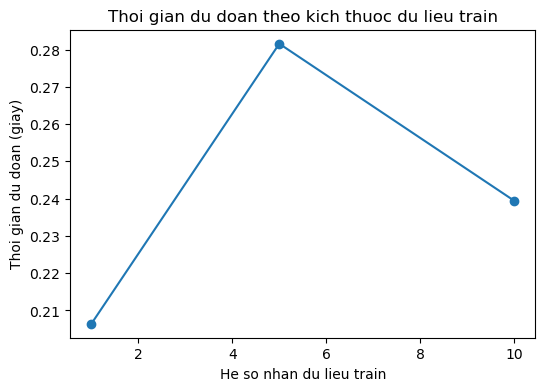

In [11]:
thoi_gian_predict = {}
for nhan in [1, 5, 10]:
    X_train_nx = pd.concat([X_train] * nhan, ignore_index=True)
    y_train_nx = pd.concat([y_train] * nhan, ignore_index=True)
    knn_nx = tao_knn(n_neighbors=k_toi_uu, weights="distance")
    knn_nx.fit(X_train_nx, y_train_nx)

    t0 = time.time()
    _ = knn_nx.predict(X_test)
    thoi_gian_predict[nhan] = time.time() - t0
    print(f"Du lieu train {nhan}x ({len(X_train_nx)} dong): du doan toan bo test mat {thoi_gian_predict[nhan]:.3f}s")

plt.figure(figsize=(6, 4))
plt.plot(list(thoi_gian_predict.keys()), list(thoi_gian_predict.values()), marker="o")
plt.xlabel("He so nhan du lieu train"); plt.ylabel("Thoi gian du doan (giay)")
plt.title("Thoi gian du doan theo kich thuoc du lieu train")
plt.show()
# KNN khong hoc mot ham so gon nhe nhu Linear/RF, moi lan du doan phai tinh khoang cach
# den TOAN BO du lieu train da luu -> du lieu train cang lon, du doan cang cham


In [12]:
import os, joblib

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

joblib.dump(knn_final, "models/knn_pipeline.joblib")

plt.figure(figsize=(8, 4))
plt.plot(K_list, rmse_train_list, label="RMSE train")
plt.plot(K_list, rmse_test_list, label="RMSE test")
plt.xlabel("K"); plt.ylabel("RMSE")
plt.title("RMSE theo K")
plt.legend()
plt.savefig("reports/rmse_theo_K.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(6, 4))
plt.plot(list(rmse_theo_he_so.keys()), list(rmse_theo_he_so.values()), marker="o")
plt.xlabel("He so nhan Lat/Lon"); plt.ylabel("RMSE")
plt.title("RMSE theo trong so vi tri")
plt.savefig("reports/trong_so_vi_tri.png", dpi=150, bbox_inches="tight"); plt.close()

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")
vi_du_can = X_train.iloc[chi_so[0]].copy()
vi_du_can["gia_that"] = y_train.iloc[chi_so[0]].values
ax.table(cellText=vi_du_can.round(2).values, colLabels=vi_du_can.columns, loc="center")
ax.set_title("5 can tuong tu (vi du can test cuoi cung)")
plt.savefig("reports/can_tuong_tu_vi_du.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(6, 4))
plt.plot(list(thoi_gian_predict.keys()), list(thoi_gian_predict.values()), marker="o")
plt.xlabel("He so nhan du lieu train"); plt.ylabel("Thoi gian du doan (giay)")
plt.title("Thoi gian du doan theo kich thuoc du lieu train")
plt.savefig("reports/thoi_gian_predict.png", dpi=150, bbox_inches="tight"); plt.close()

with open("requirements.txt", "w") as f:
    f.write("scikit-learn\npandas\nnumpy\nmatplotlib\njoblib\n")

readme_content = f"""# TT-21 - KNN Regressor: Dinh gia nha theo cac can tuong tu

## Huong dan chay
1. Cai thu vien: `pip install scikit-learn pandas numpy matplotlib joblib`
2. Notebook tu tai du lieu qua fetch_california_housing, khong can chuan bi file rieng
3. Restart Kernel roi Run All de chay dung thu tu tu dau den cuoi
4. Ket qua (model, hinh, requirements) duoc luu vao models/ va reports/ khi chay den cell cuoi

## Cac buoc da thuc hien va nhan xet

1. Nap du lieu California Housing, clip outlier AveRooms/AveBedrms/AveOccup chi theo tap train.
2. Baseline: Linear Regression RMSE={rmse_linear:.4f}, R2={r2_linear:.4f}.
3. KNN khong scale: RMSE={rmse_khong_scale:.4f} - rat kem vi Population (hang nghin) ap dao
   khoang cach so voi cac cot khac (vai don vi).
4. KNN co scale, K=5: RMSE={rmse_co_scale:.4f} - cai thien ro ret so voi khong scale.
5. Kho sat K tu 1 den 50, K toi uu tren tap test la {k_toi_uu}. Tai K=1, RMSE train luon bang 0
   vi moi diem train tu tim thay chinh no la hang xom gan nhat - day la overfit tuyet doi,
   khong duoc dung RMSE train de chon K.
6. So sanh weights: distance thuong nhinh hon uniform vi uu tien can gan hon trong K can.
7. So sanh metric: euclidean va manhattan cho ket qua gan nhau tren bo du lieu nay.
8. Thi nghiem trong so vi tri (nhan Lat/Lon x1,2,3,5): {rmse_theo_he_so}
   - RMSE {"giam" if min(rmse_theo_he_so.values()) < rmse_theo_he_so[1] else "khong cai thien them"}
   khi tang trong so vi tri, xac nhan vi tri la yeu to quan trong voi gia nha.
9. Da in ra 5 can tuong tu cho 3 can test mau (xem reports/can_tuong_tu_vi_du.png) - day la
   uu the rieng cua KNN: chi ra duoc CAN CU cu the, khac voi Linear/RF chi cho ra mot con so.
10. Bang so sanh 3 model:
{bang_so_sanh.to_string(index=False)}
11. Thoi gian du doan tang theo kich thuoc du lieu train: {thoi_gian_predict}
    - xac nhan KNN khong luu mot ham so gon nhe, phai tinh khoang cach den toan bo du lieu
    train moi lan du doan, nen cham dan khi du lieu lon.

## Han che
- KNN cham dan khi du lieu train lon, khong phu hop trien khai voi hang trieu ban ghi neu khong dung KDTree/BallTree.
- Khong ngoai suy duoc: nha co gia tri dac trung vuot xa moi can trong train se bi gan voi cac can gan nhat, khong phan anh dung xu huong ngoai bien.
- Can luu toan bo du lieu train de du doan (khong nhu Linear/RF chi can he so/cay da hoc), ton bo nho khi trien khai.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Da luu: models/knn_pipeline.joblib, reports/*.png, requirements.txt, README.md")

Da luu: models/knn_pipeline.joblib, reports/*.png, requirements.txt, README.md
